In [18]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

from pangya_physics import CLUBS, Wind, find_power

In [19]:
club = CLUBS["1W"]
wind = Wind(speed=0, degree=0)

target_distance = 200
heights = [-20, -10, 0, 10, 20, 30, 40]

In [20]:
height_results = []

for height in heights:
    result = find_power(
        club=club,
        wind=wind,
        target_distance=target_distance,
        target_height=height,
    )

    height_results.append({
        "Altura Alvo": height,
        "Power %": round(result.power_percent * 100, 2),
        "Distância Final": round(result.final_distance, 2),
        "Erro": round(result.error, 2),
        "Desvio": round(result.desvio, 4),
        "Iterações": result.iterations,
        "Encontrado": result.found,
    })

df_height = pd.DataFrame(height_results)

df_height

,Altura Alvo,Power %,Distância Final,Erro,Desvio,Iterações,Encontrado
0,-20,55.85,199.97,0.03,0.0,12,True
1,-10,61.68,199.96,0.04,0.0,10,True
2,0,70.12,200.69,-0.69,0.0,60,False
3,10,130.00,61.00,139.00,0.0,60,False
4,20,130.00,61.00,139.00,0.0,60,False
5,30,130.00,61.00,139.00,0.0,60,False
6,40,130.00,61.00,139.00,0.0,60,False


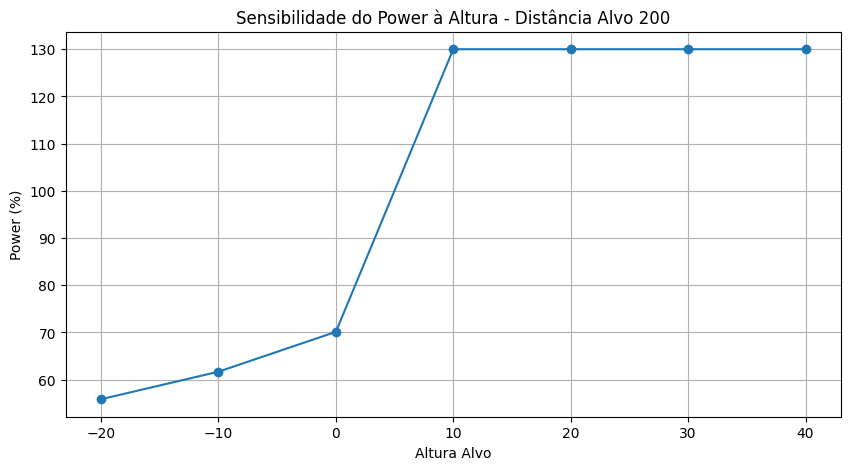

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_height["Altura Alvo"],
    df_height["Power %"],
    marker="o",
)

plt.xlabel("Altura Alvo")
plt.ylabel("Power (%)")
plt.title("Sensibilidade do Power à Altura - Distância Alvo 200")

plt.grid(True)

plt.show()

In [22]:
base_power = df_height.loc[df_height["Altura Alvo"] == 0, "Power %"].iloc[0]

df_height["Delta Power vs Altura 0"] = df_height["Power %"] - base_power

df_height

,Altura Alvo,Power %,Distância Final,Erro,Desvio,Iterações,Encontrado,Delta Power vs Altura 0
0,-20,55.85,199.97,0.03,0.0,12,True,-14.27
1,-10,61.68,199.96,0.04,0.0,10,True,-8.44
2,0,70.12,200.69,-0.69,0.0,60,False,0.00
3,10,130.00,61.00,139.00,0.0,60,False,59.88
4,20,130.00,61.00,139.00,0.0,60,False,59.88
5,30,130.00,61.00,139.00,0.0,60,False,59.88
6,40,130.00,61.00,139.00,0.0,60,False,59.88


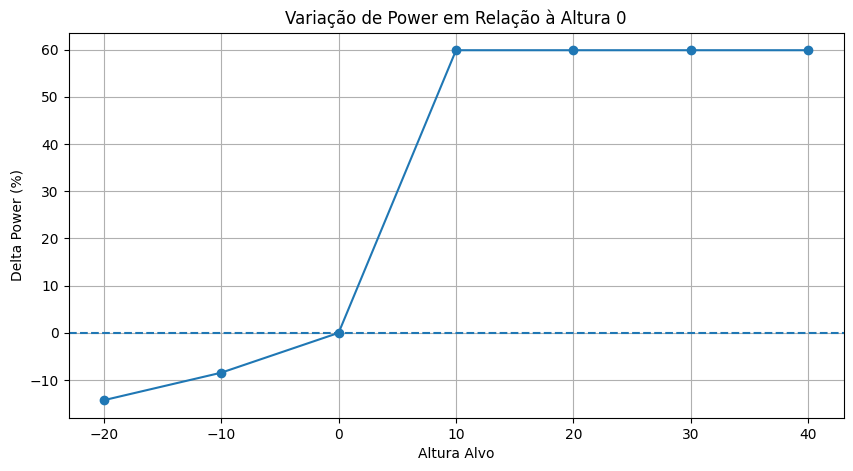

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_height["Altura Alvo"],
    df_height["Delta Power vs Altura 0"],
    marker="o",
)

plt.axhline(0, linestyle="--")

plt.xlabel("Altura Alvo")
plt.ylabel("Delta Power (%)")
plt.title("Variação de Power em Relação à Altura 0")

plt.grid(True)

plt.show()

In [24]:
from pangya_physics import CLUBS, Wind
from pangya_physics.solver import create_initial_velocity
from pangya_physics import Ball, PangyaSimulator

club = CLUBS["1W"]

ball = Ball(
    velocity=create_initial_velocity(
        club=club,
        power_percent=0.70,
    )
)

sim = PangyaSimulator(
    ball=ball,
    club=club,
    wind=Wind(speed=0, degree=0),
)

dados = []

for _ in range(100):

    sim.step()

    dados.append({
        "step": sim.ball.count,
        "y": sim.ball.position.y,
        "z": sim.ball.position.z,
    })

import pandas as pd

traj = pd.DataFrame(dados)

traj.head(20)

,step,y,z
0,1,0.542293,3.153295
1,2,1.067845,6.289015
2,3,1.576769,9.407369
3,4,2.069173,12.508560
4,5,2.545166,15.592789
5,6,3.004854,18.660252
6,7,3.448339,21.711142
7,8,3.875725,24.745648
8,9,4.287112,27.763956
9,10,4.682597,30.766249


In [25]:
traj["y"].max()

np.float64(9.670389084589974)

In [26]:
from pangya_physics import Ball, PangyaSimulator, CLUBS, Wind
from pangya_physics.solver import create_initial_velocity

club = CLUBS["1W"]
wind = Wind(speed=0, degree=0)

target_height = 10
power_percents = [0.5, 0.7, 0.9, 1.1, 1.3]

diagnostico = []

for power_percent in power_percents:
    ball = Ball(
        velocity=create_initial_velocity(
            club=club,
            power_percent=power_percent,
        )
    )

    sim = PangyaSimulator(ball=ball, club=club, wind=wind)

    max_height = 0
    collision_z = None

    previous_y = sim.ball.position.y

    for _ in range(3000):
        sim.step()

        max_height = max(max_height, sim.ball.position.y)

        crossed_height_descending = (
            previous_y >= target_height
            and sim.ball.position.y <= target_height
            and sim.ball.velocity.y < 0
            and sim.ball.count > 10
        )

        if crossed_height_descending:
            collision_z = sim.ball.position.z
            break

        previous_y = sim.ball.position.y

    diagnostico.append({
        "Power %": round(power_percent * 100, 2),
        "Altura Máxima": round(max_height, 2),
        "Distância ao cruzar altura +10": None if collision_z is None else round(collision_z, 2),
    })

pd.DataFrame(diagnostico)

,Power %,Altura Máxima,Distância ao cruzar altura +10
0,50.0,5.20,NaN
1,70.0,9.67,NaN
2,90.0,14.94,235.85
3,110.0,20.67,337.48
4,130.0,26.62,427.41


In [27]:
from pangya_physics import CLUBS
from pangya_physics.solver import create_initial_velocity

club = CLUBS["1W"]

for power in [0.5, 0.7, 0.9, 1.1, 1.3]:
    v = create_initial_velocity(club, power)

    print(
        f"Power={power:.1f} | "
        f"Vy={v.y:.2f} | "
        f"Vz={v.z:.2f}"
    )

Power=0.5 | Vy=19.97 | Vz=113.25
Power=0.7 | Vy=27.96 | Vz=158.55
Power=0.9 | Vy=35.95 | Vz=203.86
Power=1.1 | Vy=43.93 | Vz=249.16
Power=1.3 | Vy=51.92 | Vz=294.46
